In [1]:
# Basado en: https://medium.com/@stepanulyanin/implementing-grad-cam-in-pytorch-ea0937c31e82

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
from torchvision.models import vgg19
from torchvision import transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import os
import numpy as np
import requests
from PIL import Image
import cv2

# Usamos la transformación de ImageNet
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# Definimos un dataset
dataset = datasets.ImageFolder(root='drive/My Drive/animals', transform=transform)

# Definimos el data loader que cargará las imágenes
dataloader = data.DataLoader(dataset=dataset, shuffle=False, batch_size=1)

In [4]:
class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()

        # VGG19 pre-entrenada
        self.vgg = vgg19(pretrained=True)

        # Diseccionamos la red para acceder a su última capa convolucional
        self.features_conv = self.vgg.features[:36]

        # Max pool
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

        # Obtenemos el clasificador vgg19
        self.classifier = self.vgg.classifier

        # gradientes
        self.gradients = None

    # Hook para guardar las activaciones de los gradientes
    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        # Aplicamos las primeras 36 capas de VGG19
        x = self.features_conv(x)

        # Registramos el hook
        # El hook será llamado cuando un gradiente respecto a x sea computado
        # Y nos servirá para guardarnos los gradientes respecto a la última capa convolucional
        # https://pytorch.org/docs/stable/generated/torch.Tensor.register_hook.html
        # Esto es necesario porque:
        # PyTorch solo cachea el gradiente de los nodos hoja en el grafo de cómputo, como pesos, sesgos, y otros parámetros.
        # Los gradientes de la salida con respecto a la activación son meramente valores intermedios y son descartados
        # ni bien el gradiente se propaga a través de ellos.
        h = x.register_hook(self.activations_hook)

        # Aplicamos manualmente el pooling y el classifier
        x = self.max_pool(x)
        x = x.view((1, -1)) # Size -1 se infiere de las otras dimensiones
        x = self.classifier(x)
        return x

    # Extracción del gradiente
    def get_activations_gradient(self):
        return self.gradients

    # Activaciones
    def get_activations(self, x):
        return self.features_conv(x)

In [5]:
from IPython.display import Image

In [6]:
it = iter(dataloader)

In [7]:
# inicializa el modelo VGG
vgg = VGG()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 153MB/s]


In [8]:
def get_next_heatmap(vgg, it):
  # especifica modo evaluación
  vgg.eval()

  # obtiene la imágen del dataloader
  img, _ = next(it)

  # obtiene la predicción del modelo
  pred = vgg(img)

  index = pred.argmax(dim=1)
  print(index)

  # Obtiene el gradiente del output con respecto a los parámetros del modelo
  pred[:, index.item()].backward()

  # Obtenemos los gradientes del modelo
  gradients = vgg.get_activations_gradient()

  print(gradients.shape)

  # Distribuímos los gradientes a través de todos los canales
  pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

  # Obtenemos las activaciones de la última capa convolucional
  activations = vgg.get_activations(img).detach()

  # Pesamos los canales por su peso correspondiente
  for i in range(512):
    activations[:, i, :, :] *= pooled_gradients[i]

  # Promediamos los canales de la activación
  heatmap = torch.mean(activations, dim=1).squeeze()

  # ReLU sobre el heatmap
  # Expresión (2) in https://arxiv.org/pdf/1610.02391.pdf
  heatmap = F.relu(heatmap)

  # Normalizamos el heatmap
  heatmap /= torch.max(heatmap)

  return heatmap.squeeze()

tensor([153])
torch.Size([1, 512, 14, 14])


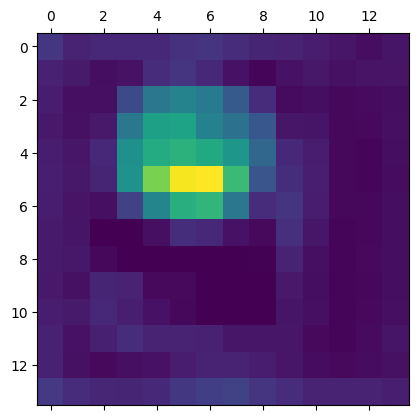

In [9]:
heatmap = get_next_heatmap(vgg, it)
# Dibujamos el heatmap
plt.matshow(heatmap)

In [10]:
def print_image_plus_heatmap(heatmap, image_path):
  img = cv2.imread(image_path)
  print(heatmap.shape)
  print(img.shape)
  heatmap = cv2.resize(heatmap.numpy(), (img.shape[1], img.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
  superimposed_img = heatmap * 0.4 + img
  cv2.imwrite('./map.jpg', superimposed_img)
  return Image("map.jpg", width=500, height=500)

torch.Size([14, 14])
(640, 959, 3)


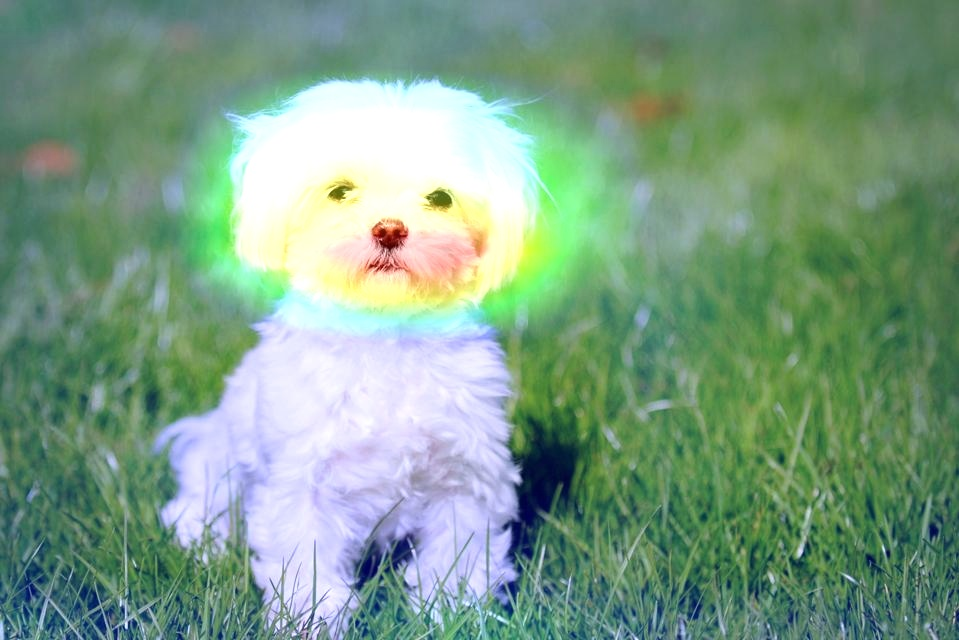

In [11]:
img = print_image_plus_heatmap(heatmap, 'drive/My Drive/animals/dog/dog.jpeg')
img

tensor([386])
torch.Size([1, 512, 14, 14])


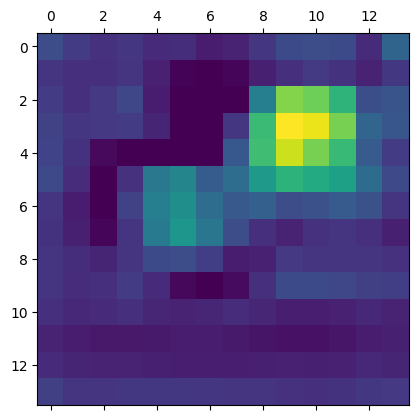

In [12]:
heatmap = get_next_heatmap(vgg, it)
# Dibujamos el heatmap
plt.matshow(heatmap)

torch.Size([14, 14])
(280, 419, 3)


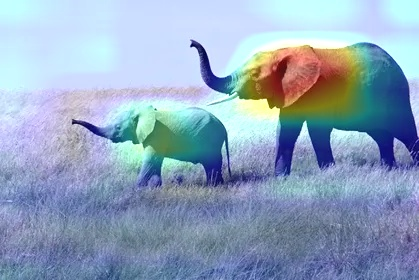

In [13]:
img = print_image_plus_heatmap(heatmap, 'drive/My Drive/animals/elephant/1_kc-k_j53HOJH_sifhg4lHg.webp')
img

tensor([2])
torch.Size([1, 512, 14, 14])


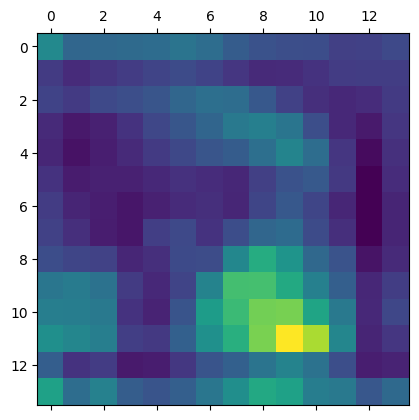

In [14]:
heatmap = get_next_heatmap(vgg, it)
# Dibujamos el heatmap
plt.matshow(heatmap)

torch.Size([14, 14])
(423, 500, 3)


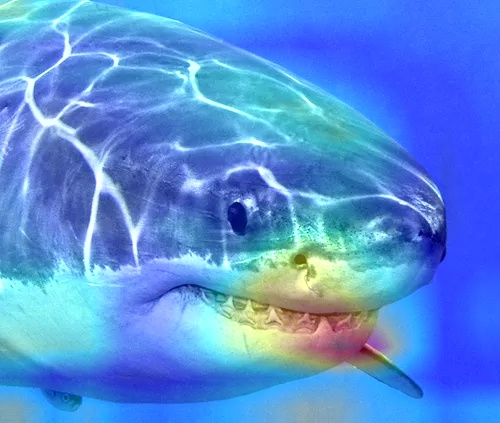

In [15]:
img = print_image_plus_heatmap(heatmap, 'drive/My Drive/animals/shark/1_506ySAThs6pItevFqZF-4g.webp')
img